In [2]:
library(ComplexHeatmap)
library(dplyr)
library(RColorBrewer)
library(circlize)  # 用于自定义颜色
library(dendextend) 
library(NbClust)
library(ggplot2)
library(ggpubr)
library(tidyr)
library(viridis)
library(readxl)

Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.3.2”
Loading required package: grid

ComplexHeatmap version 2.18.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, u

In [2]:
load("/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_samefeature(500fg)_nature.Rdata")

In [3]:
load("/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_samefeature(500fg)_nature_gender.Rdata")

In [3]:
# protein_500fg_names <- readRDS("/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_protein_rownames.Rdata")
# print(protein_500fg_names)
# length(protein_500fg_names)
###set protein name same order 
ref <- readRDS("/vol/projects/yzhang/500FG_aging/output/14_AA/heatmap_500fg_cyto_pro_row_gender_order.rds")
str(ref)
protein_500fg_names <- ref$protein
print(protein_500fg_names)
length(protein_500fg_names)

List of 2
 $ cytokine: chr [1:19] "IL6_C.albicanshyphae_PBMC_24h" "IL6_A.fumigatusconidiaSerum_PBMC_24h" "IFNy_Bacteroides_PBMC_7days" "IL17_Bacteroides_PBMC_7days" ...
 $ protein : chr [1:37] "IL18" "CCL25" "MCP_1" "IL_15RA" ...
 [1] "IL18"           "CCL25"          "MCP_1"          "IL_15RA"       
 [5] "CCL3"           "IL6"            "IL8"            "CDCP1"         
 [9] "CST5"           "Flt3L"          "VEGFA"          "MCP_2"         
[13] "OPG"            "CCL4"           "HGF"            "MCP_4"         
[17] "CCL11"          "MMP_1"          "CCL28"          "CXCL10"        
[21] "CXCL11"         "CXCL9"          "CXCL1"          "CXCL5"         
[25] "CASP_8"         "LAP_TGF_beta_1" "CD40"           "IL_10RB"       
[29] "CX3CL1"         "TRANCE"         "IL_12B"         "TNFRSF9"       
[33] "CD5"            "TNFB"           "CD8A"           "SCF"           
[37] "NT_3"          


[1] 37

In [8]:
protein <- readRDS("/vol/projects/yzhang/300BCG/output/02_protein/olink_baseline_filter.RDS")
head(protein)
dim(protein)
sum(is.na(protein))

,IL8,VEGFA,CD8A,GDNF,CDCP1,CD244,IL7,OPG,LAP_TGF_beta_1,uPA,⋯,CX3CL1,TNFRSF9,NT_3,TWEAK,CCL20,ST1A1,STAMPB,ADA,TNFB,CSF_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,4.29061,9.91262,10.72095,0.91757,1.82626,6.16599,2.52509,10.49372,7.22726,9.52939,⋯,5.59913,6.67910,2.54220,9.73740,5.07433,1.95864,4.84613,3.09911,4.69753,10.00918
3,4.29681,9.96759,10.72574,1.51044,2.42619,6.50292,2.19194,11.19845,7.03600,9.45816,⋯,5.86704,6.39154,2.36277,10.18412,6.08405,0.91842,4.32113,3.46515,5.08216,9.92566
4,4.91254,9.67740,10.33196,1.87342,2.45593,7.01079,3.03914,10.14246,7.01351,10.19292,⋯,6.60482,7.01200,2.82704,10.78360,6.97021,3.30563,5.81402,3.56631,5.52844,9.80639
5,4.68774,10.08885,11.77968,1.75349,2.50487,6.68944,3.02304,10.46279,6.95474,10.30165,⋯,6.23140,6.66037,2.73015,10.57543,6.04535,3.19350,5.75345,4.59007,4.93332,9.88342
6,5.52716,9.79930,10.74708,2.16935,2.83062,6.97783,3.00670,10.40283,7.24161,10.44221,⋯,6.22438,7.18973,2.55210,10.64993,6.14130,3.88393,6.38890,4.34941,5.43401,9.89399
7,4.63820,9.65995,12.21898,2.12286,2.45167,6.80069,3.04662,10.20358,7.06388,10.39517,⋯,6.47795,7.42191,2.77117,10.96280,5.55960,2.72744,5.56986,3.93287,5.99324,9.87584


[1] 318  72

[1] 0

In [4]:
cytokine_corr <- read.csv("/vol/projects/yzhang/300BCG/output/01_cytokine/filtered_cytokine_name_replace_base.csv",row.names=1) ##no same feature，but use all cytokine feature
head(cytokine_corr)
dim(cytokine_corr)
cytokine_filtered <- cytokine_corr

,IL1b_S.aureus_PBMC_24h,IL1b_M.tuberculosis_PBMC_24h,IL6_S.aureus_PBMC_24h,IL6_M.tuberculosis_PBMC_24h,TNF_S.aureus_PBMC_24h,IFNg_S.aureus_PBMC_7days,IFNg_M.tuberculosis_PBMC_7days
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3.381887,1.760521,3.391737,3.413822,3.057315,2.059834,3.374612
2,3.228925,1.964365,3.138341,3.485255,2.530539,2.938095,3.703288
3,3.471028,1.369958,3.767929,3.443301,2.836585,2.432884,2.906826
4,3.088538,1.318230,3.162707,3.413822,2.118741,NA,2.738968
5,3.454589,2.432666,3.455869,3.690989,2.424113,2.264152,3.137723
7,3.210198,2.230978,3.072600,3.625928,3.132922,3.864022,3.894390


[1] 311   7

In [4]:
#matching_columns <- intersect(colnames(protein), protein_500fg_names)
matching_columns <- protein_500fg_names[protein_500fg_names %in% colnames(protein)] ##change to same order
protein_subset <- protein[, matching_columns, drop = FALSE]
head(protein_subset)
dim(protein_subset)

,IL18,CCL25,MCP_1,CCL3,IL6,IL8,CDCP1,CST5,Flt3L,VEGFA,⋯,IL_10RB,CX3CL1,TRANCE,IL_12B,TNFRSF9,CD5,TNFB,CD8A,SCF,NT_3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,8.42142,4.86754,10.32131,5.17292,2.37600,4.29061,1.82626,7.80028,10.08600,9.91262,⋯,6.00460,5.59913,5.04969,5.68668,6.67910,4.84314,4.69753,10.72095,9.13313,2.54220
3,8.52163,6.89609,9.93532,4.59647,1.98837,4.29681,2.42619,7.04515,10.13689,9.96759,⋯,6.53214,5.86704,3.53332,5.86733,6.39154,4.84240,5.08216,10.72574,9.51683,2.36277
4,8.67183,5.29403,10.48295,5.27671,2.15050,4.91254,2.45593,7.17810,9.73370,9.67740,⋯,6.41552,6.60482,4.12193,5.12712,7.01200,4.93239,5.52844,10.33196,10.64025,2.82704
5,8.13229,5.37510,10.53249,5.26384,2.50712,4.68774,2.50487,6.38029,9.42678,10.08885,⋯,6.72822,6.23140,4.02952,5.83474,6.66037,5.04836,4.93332,11.77968,10.31680,2.73015
6,9.18842,6.58699,10.52262,5.87658,1.91751,5.52716,2.83062,6.63489,10.44798,9.79930,⋯,6.45046,6.22438,4.95703,5.90224,7.18973,4.98171,5.43401,10.74708,10.18465,2.55210
7,8.22007,6.18136,10.53149,5.59837,2.40621,4.63820,2.45167,6.94788,9.97443,9.65995,⋯,6.07496,6.47795,5.22738,6.48647,7.42191,5.29013,5.99324,12.21898,10.51486,2.77117


[1] 318  36

In [14]:
pheno = read_excel("/vol/projects/CIIM/300BCG/201103 300BCG Age and sex data.xlsx")
head(pheno)
dim(pheno)
sum(is.na(pheno$Age))

PatientID,Gender,Age,Length,Weight,BMI
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,female,23,170,61,21.10727
2,female,20,173,73,24.39106
3,female,22,176,63,20.33833
4,female,22,175,59,19.26531
5,female,18,170,61,21.10727
6,male,20,178,75,23.67125


[1] 321   6

[1] 0

In [5]:
# # 找到三个数据集共有的样本 ID
# common_samples <- intersect(rownames(protein_subset), pheno$PatientID)
# # 过滤出共同样本
# protein_filtered <- protein_subset[common_samples, , drop = FALSE]
# basicPhenos_filtered <- pheno[pheno$PatientID %in% common_samples, , drop = FALSE]
# basicPhenos_filtered <- as.data.frame(basicPhenos_filtered)
# # 重新设置 basicPhenos_filtered 的行名，使其与 common_samples 一致
# rownames(basicPhenos_filtered) <- basicPhenos_filtered$PatientID

# # 确保 basicPhenos_filtered 只包含共有样本
# basicPhenos_filtered <- basicPhenos_filtered[common_samples, , drop = FALSE]

# # 合并数据（保留所有特征）
# merged_data <- data.frame(
#   Sample_ID = common_samples,
#   Age = basicPhenos_filtered$Age,  # Age 对齐
#   protein_filtered  # 所有细胞因子特征
# )

# # 查看合并后的数据
# head(merged_data)
# dim(merged_data)  # 查看合并后的行数和列数


,Sample_ID,Age,IL18,CCL25,MCP_1,CCL3,IL6,IL8,CDCP1,CST5,⋯,IL_10RB,CX3CL1,TRANCE,IL_12B,TNFRSF9,CD5,TNFB,CD8A,SCF,NT_3
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,23,8.42142,4.86754,10.32131,5.17292,2.37600,4.29061,1.82626,7.80028,⋯,6.00460,5.59913,5.04969,5.68668,6.67910,4.84314,4.69753,10.72095,9.13313,2.54220
3,3,22,8.52163,6.89609,9.93532,4.59647,1.98837,4.29681,2.42619,7.04515,⋯,6.53214,5.86704,3.53332,5.86733,6.39154,4.84240,5.08216,10.72574,9.51683,2.36277
4,4,22,8.67183,5.29403,10.48295,5.27671,2.15050,4.91254,2.45593,7.17810,⋯,6.41552,6.60482,4.12193,5.12712,7.01200,4.93239,5.52844,10.33196,10.64025,2.82704
5,5,18,8.13229,5.37510,10.53249,5.26384,2.50712,4.68774,2.50487,6.38029,⋯,6.72822,6.23140,4.02952,5.83474,6.66037,5.04836,4.93332,11.77968,10.31680,2.73015
6,6,20,9.18842,6.58699,10.52262,5.87658,1.91751,5.52716,2.83062,6.63489,⋯,6.45046,6.22438,4.95703,5.90224,7.18973,4.98171,5.43401,10.74708,10.18465,2.55210
7,7,25,8.22007,6.18136,10.53149,5.59837,2.40621,4.63820,2.45167,6.94788,⋯,6.07496,6.47795,5.22738,6.48647,7.42191,5.29013,5.99324,12.21898,10.51486,2.77117


[1] 318  38

In [6]:
common_samples <- intersect(intersect(rownames(cytokine_filtered), 
                                      rownames(protein_filtered)), 
                            pheno$PatientID)

# Filter out common samples
cytokine_common <- cytokine_filtered[common_samples, , drop = FALSE]
protein_common <- protein_filtered[common_samples, , drop = FALSE]
pheno_common <- pheno[pheno$PatientID %in% common_samples, , drop = FALSE]

# Reset row names of basicPhenos_filtered to match common_samples
rownames(pheno_common) <- pheno_common$PatientID
# Ensure basicPhenos_filtered only contains common samples
pheno_common <- pheno_common[common_samples, , drop = FALSE]

# Merge data (retain all features)
merged_data <- data.frame(
  Sample_ID = common_samples,
  Age = pheno_common$Age,  # Age alignment
  cytokine_common,  # All cytokine features
  protein_common    # All protein features
)

# View merged data
head(merged_data)
dim(merged_data) 

Warning message:
“Setting row names on a tibble is deprecated.”


,Sample_ID,Age,IL1b_S.aureus_PBMC_24h,IL1b_M.tuberculosis_PBMC_24h,IL6_S.aureus_PBMC_24h,IL6_M.tuberculosis_PBMC_24h,TNF_S.aureus_PBMC_24h,IFNg_S.aureus_PBMC_7days,IFNg_M.tuberculosis_PBMC_7days,IL18,⋯,IL_10RB,CX3CL1,TRANCE,IL_12B,TNFRSF9,CD5,TNFB,CD8A,SCF,NT_3
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,23,3.381887,1.760521,3.391737,3.413822,3.057315,2.059834,3.374612,8.42142,⋯,6.00460,5.59913,5.04969,5.68668,6.67910,4.84314,4.69753,10.72095,9.13313,2.54220
3,3,22,3.471028,1.369958,3.767929,3.443301,2.836585,2.432884,2.906826,8.52163,⋯,6.53214,5.86704,3.53332,5.86733,6.39154,4.84240,5.08216,10.72574,9.51683,2.36277
4,4,22,3.088538,1.318230,3.162707,3.413822,2.118741,NA,2.738968,8.67183,⋯,6.41552,6.60482,4.12193,5.12712,7.01200,4.93239,5.52844,10.33196,10.64025,2.82704
5,5,18,3.454589,2.432666,3.455869,3.690989,2.424113,2.264152,3.137723,8.13229,⋯,6.72822,6.23140,4.02952,5.83474,6.66037,5.04836,4.93332,11.77968,10.31680,2.73015
7,7,25,3.210198,2.230978,3.072600,3.625928,3.132922,3.864022,3.894390,8.22007,⋯,6.07496,6.47795,5.22738,6.48647,7.42191,5.29013,5.99324,12.21898,10.51486,2.77117
8,8,22,3.160150,1.440106,2.957915,2.918308,2.666525,2.420270,2.966891,7.89332,⋯,6.85019,6.46407,3.52008,4.80039,6.70238,4.85497,4.94515,10.38591,9.53401,2.32204


[1] 308  45

In [81]:
write.csv(merged_data,"/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_merge_data.csv",row.names=TRUE)

pdf 
  2

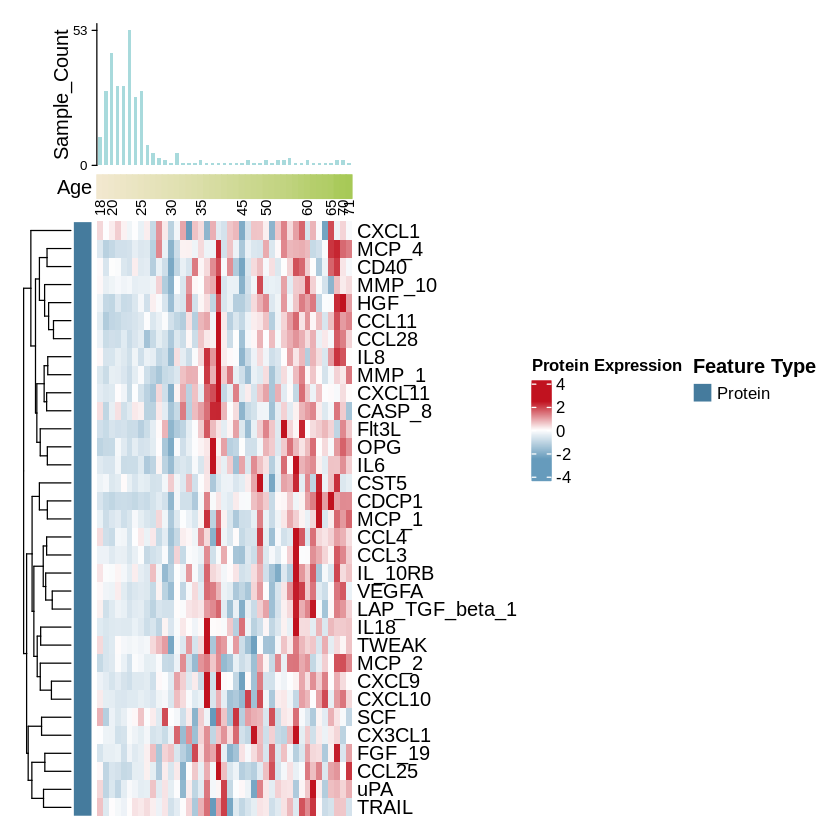

In [22]:
heatmap_data <- merged_data[, !(colnames(merged_data) %in% c("Sample_ID", "Age"))]

# 1. **Ensure Age is sorted in order**
sorted_indices <- order(merged_data$Age, na.last = FALSE)
heatmap_data_sorted <- heatmap_data[sorted_indices, , drop = FALSE]
age_sorted <- merged_data$Age[sorted_indices]

# 2. **Remove NA and synchronize Age**
valid_rows <- complete.cases(heatmap_data_sorted)  # Ensure all rows have no NA
heatmap_data_sorted <- heatmap_data_sorted[valid_rows, , drop = FALSE]
age_sorted <- age_sorted[valid_rows]

# 3. **Convert DataFrame and merge Age**
heatmap_data_sorted <- as.data.frame(heatmap_data_sorted)
heatmap_data_sorted$Age <- age_sorted

# 4. **Group by Age and calculate median**
heatmap_data_grouped <- heatmap_data_sorted %>%
  group_by(Age) %>%
  summarise(across(everything(), median, na.rm = TRUE)) %>%
  ungroup() %>%
  arrange(Age)  # Ensure Age is still in ascending order

# Separate data BEFORE transposin
age_sorted <- heatmap_data_grouped$Age
heatmap_data_grouped_matrix <- as.matrix(select(heatmap_data_grouped, -Age))

# 7. **Create Feature Type vector** - All features are Protein type
# feature_types <- rep("Protein", ncol(heatmap_data_grouped))
# # 5. **Separate data by Feature Type BEFORE transposing**
# protein_cols <- which(feature_types == "Protein")

# protein_data_original <- heatmap_data_grouped_matrix[, protein_cols, drop = FALSE]

# # Transpose each data type separately
# protein_data <- t(protein_data_original)
protein_data_original <- heatmap_data_grouped_matrix
protein_data <- t(protein_data_original)

# 6. **Calculate sample counts for each Age group**
age_counts <- as.data.frame(table(merged_data$Age))  # Count original Age occurrences
colnames(age_counts) <- c("Age", "Count")  # Ensure clear column names
age_counts$Age <- as.numeric(as.character(age_counts$Age))  # Convert to numeric

# 7. **Merge sample counts to age_sorted (after grouping)**
age_counts_sorted <- age_counts[match(age_sorted, age_counts$Age), ]  # Ensure order matches
sample_counts <- ifelse(is.na(age_counts_sorted$Count), 0, age_counts_sorted$Count)  # Avoid NA

# 8. **Ensure sample_counts length matches heatmap columns**
# sample_counts should have the same length as the number of age groups in the heatmap
stopifnot(length(sample_counts) == length(age_sorted))

# 8. **Update Age Labels to show (n=sample_count)**
age_labels <- ifelse(
  age_sorted %in% c(min(age_sorted), max(age_sorted)) | age_sorted %% 5 == 0, 
  # paste0(as.character(age_sorted), " (n=", sample_counts, ")"),  # Format: "Age (n=X)" - commented out
  as.character(age_sorted),  # Show only age without sample count
  ""  # Keep blank elsewhere
)

# 23. **Apply z-score normalization to each Feature Type separately**
# Function to calculate z-score for each feature (row)
zscore_data <- function(data_matrix) {
  zscore_matrix <- t(apply(data_matrix, 1, function(x) {
    x_mean <- mean(x, na.rm = TRUE)
    x_sd <- sd(x, na.rm = TRUE)
    
    # Handle constant values (zero variance)
    if (is.na(x_sd) || x_sd == 0) {
      return(rep(0, length(x)))
    }
    
    return((x - x_mean) / x_sd)
  }))
  return(zscore_matrix)
}

# Apply z-score normalization to each Feature Type
protein_data_zscore <- zscore_data(protein_data)

# Create appropriate color functions for z-score data
protein_zscore_range <- range(protein_data_zscore, na.rm = TRUE)

# Create symmetric color scales centered at 0
max_protein_abs <- max(abs(protein_zscore_range))

# Truncate to 2.5 standard deviations for better visualization
protein_limit <- min(max_protein_abs, 2.5)

# Color functions for z-score data with truncation
protein_col_fun <- colorRamp2(
  breaks = seq(-protein_limit, protein_limit, length.out = 100),
  colors = colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)

# Create breaks for legends (use truncated limits)
protein_breaks <- round(seq(-protein_limit, protein_limit, length.out = 7), 2)

age_col_fun <- colorRamp2(
  breaks = c(min(age_sorted), max(age_sorted)),
  colors = c("#f2e8cf", "#a7c957")
)

# Protein heatmap - 添加top_annotation
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Protein Expression",
  cluster_rows = TRUE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  col = protein_col_fun,
  row_dend_reorder = FALSE,
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = 9), rot = 90),
    annotation_name_side = "left"
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(4, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE
)

# 25. **Create legends for separate heatmaps**
protein_legend <- Legend(
  title = "Protein Expression", 
  col_fun = protein_col_fun,
  at = protein_breaks,
  labels = protein_breaks
)

feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = 12, fontface = "bold"),
#   at = c("Cytokine stimulus pair", "Protein"),
#   legend_gp = gpar(fill = c("#e63946", "#457b9d"))
# )
  at = c("Protein"),
  legend_gp = gpar(fill = c("#457b9d"))
)
# 26. **Create sample count bar chart annotation**
sample_count_anno <- HeatmapAnnotation(
  Sample_Count = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(3, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = 8)
    ),
    border = FALSE  # Remove border
  ),
  annotation_name_side = "left"  # Move annotation name to left
)
# 27. **Combine separate heatmaps vertically with sample count annotation**
heatmap_combined_separate <- sample_count_anno %v% protein_heatmap

# 28. **Save separate version to PDF**
pdf("/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_transposed_bar_zscore_cluster_samefeature(500fg).pdf", width = 18, height = 15, onefile = FALSE)

draw(
  heatmap_combined_separate,
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "right",
  annotation_legend_side = "right",
  padding = unit(c(15, 15, 15, 15), "mm")
)

dev.off()

#29. **Display separate version on screen**
draw(
  heatmap_combined_separate,
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "right",
  annotation_legend_side = "right",
  padding = unit(c(5, 5, 5, 5), "mm")
)


In [21]:
save.image("/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_samefeature(500fg).Rdata")

In [9]:
##same feature and same order
heatmap_data <- merged_data[, !(colnames(merged_data) %in% c("Sample_ID", "Age"))]

# 1. **Ensure Age is sorted in order**
sorted_indices <- order(merged_data$Age, na.last = FALSE)
heatmap_data_sorted <- heatmap_data[sorted_indices, , drop = FALSE]
age_sorted <- merged_data$Age[sorted_indices]

# 2. **Remove NA and synchronize Age**
valid_rows <- complete.cases(heatmap_data_sorted)  # Ensure all rows have no NA
heatmap_data_sorted <- heatmap_data_sorted[valid_rows, , drop = FALSE]
age_sorted <- age_sorted[valid_rows]

# 3. **Convert DataFrame and merge Age**
heatmap_data_sorted <- as.data.frame(heatmap_data_sorted)
heatmap_data_sorted$Age <- age_sorted

# 4. **Group by Age and calculate median**
heatmap_data_grouped <- heatmap_data_sorted %>%
  group_by(Age) %>%
  summarise(across(everything(), median, na.rm = TRUE)) %>%
  ungroup() %>%
  arrange(Age)  # Ensure Age is still in ascending order

# Separate data BEFORE transposin
age_sorted <- heatmap_data_grouped$Age
heatmap_data_grouped_matrix <- as.matrix(select(heatmap_data_grouped, -Age))

#7. **Create Feature Type vector** - All features are Protein type
feature_types <- rep("Protein", ncol(heatmap_data_grouped))
# 5. **Separate data by Feature Type BEFORE transposing**
protein_cols <- which(feature_types == "Protein")

protein_data_original <- heatmap_data_grouped_matrix[, protein_cols, drop = FALSE]

# # Transpose each data type separately
# protein_data <- t(protein_data_original)
protein_data_original <- heatmap_data_grouped_matrix
protein_data <- t(protein_data_original)

# 6. **Calculate sample counts for each Age group**
age_counts <- as.data.frame(table(merged_data$Age))  # Count original Age occurrences
colnames(age_counts) <- c("Age", "Count")  # Ensure clear column names
age_counts$Age <- as.numeric(as.character(age_counts$Age))  # Convert to numeric

# 7. **Merge sample counts to age_sorted (after grouping)**
age_counts_sorted <- age_counts[match(age_sorted, age_counts$Age), ]  # Ensure order matches
sample_counts <- ifelse(is.na(age_counts_sorted$Count), 0, age_counts_sorted$Count)  # Avoid NA

# 8. **Ensure sample_counts length matches heatmap columns**
# sample_counts should have the same length as the number of age groups in the heatmap
stopifnot(length(sample_counts) == length(age_sorted))

# 8. **Update Age Labels to show (n=sample_count)**
age_labels <- ifelse(
  age_sorted %in% c(min(age_sorted), max(age_sorted)) | age_sorted %% 5 == 0, 
  # paste0(as.character(age_sorted), " (n=", sample_counts, ")"),  # Format: "Age (n=X)" - commented out
  as.character(age_sorted),  # Show only age without sample count
  ""  # Keep blank elsewhere
)

# 23. **Apply z-score normalization to each Feature Type separately**
# Function to calculate z-score for each feature (row)
zscore_data <- function(data_matrix) {
  zscore_matrix <- t(apply(data_matrix, 1, function(x) {
    x_mean <- mean(x, na.rm = TRUE)
    x_sd <- sd(x, na.rm = TRUE)
    
    # Handle constant values (zero variance)
    if (is.na(x_sd) || x_sd == 0) {
      return(rep(0, length(x)))
    }
    
    return((x - x_mean) / x_sd)
  }))
  return(zscore_matrix)
}

# Apply z-score normalization to each Feature Type
protein_data_zscore <- zscore_data(protein_data)

# Create appropriate color functions for z-score data
protein_zscore_range <- range(protein_data_zscore, na.rm = TRUE)

# Create symmetric color scales centered at 0
max_protein_abs <- max(abs(protein_zscore_range))

# Truncate to 2.5 standard deviations for better visualization
protein_limit <- min(max_protein_abs, 2.5)

# Color functions for z-score data with truncation
protein_col_fun <- colorRamp2(
  breaks = seq(-protein_limit, protein_limit, length.out = 100),
  colors = colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)

# Create breaks for legends (use truncated limits)
protein_breaks <- round(seq(-protein_limit, protein_limit, length.out = 7), 2)


age_col_fun <- colorRamp2(
  breaks = c(min(age_sorted), max(age_sorted)),
  colors = c("#f2e8cf", "#a7c957")
)

# Protein heatmap - 添加top_annotation
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Proteomics Z-score",
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  col = protein_col_fun,
  row_dend_reorder = FALSE,
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = 9), rot = 0),
    annotation_name_side = "left"
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(4, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE
)

# 25. **Create legends for separate heatmaps**
protein_legend <- Legend(
  title = "Proteomics Z-score", 
  col_fun = protein_col_fun,
  at = protein_breaks,
  labels = protein_breaks
)

feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = 12, fontface = "bold"),
#   at = c("Cytokine stimulus pair", "Protein"),
#   legend_gp = gpar(fill = c("#e63946", "#457b9d"))
# )
  at = c("Proteomics"),
  legend_gp = gpar(fill = c("#457b9d"))
)

# 26. **Create sample count bar chart annotation**
sample_count_anno <- HeatmapAnnotation(
  Sample_Count = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(3, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = 8)
    ),
    border = FALSE  # Remove border
  ),
  annotation_name_side = "left"  # Move annotation name to left
)
# 27. **Combine separate heatmaps vertically with sample count annotation**
heatmap_combined_separate <- sample_count_anno %v% protein_heatmap


# 28. **Save separate version to PDF**
# pdf("/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap__zscore_cluster_samefeature_order(500fg)_gender_cytokine.pdf", width = 18, height = 18, onefile = FALSE)

# draw(
#   heatmap_combined_separate,
#   show_heatmap_legend = TRUE,
#   show_annotation_legend = TRUE,
#    annotation_legend_list = list(feature_type_legend_separate),
#    heatmap_legend_side = "right",
#   annotation_legend_side = "right",
#   merge_legends = TRUE,
#   padding = unit(c(15, 15, 15, 15), "mm")
# )

# dev.off()

#29. **Display separate version on screen**
draw(
  heatmap_combined_separate,
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "right",
  annotation_legend_side = "right",
  merge_legends = TRUE,
  padding = unit(c(5, 5, 5, 5), "mm")
)


ERROR: Error in heatmap_data_grouped_matrix[, protein_cols, drop = FALSE]: subscript out of bounds


pdf 
  2

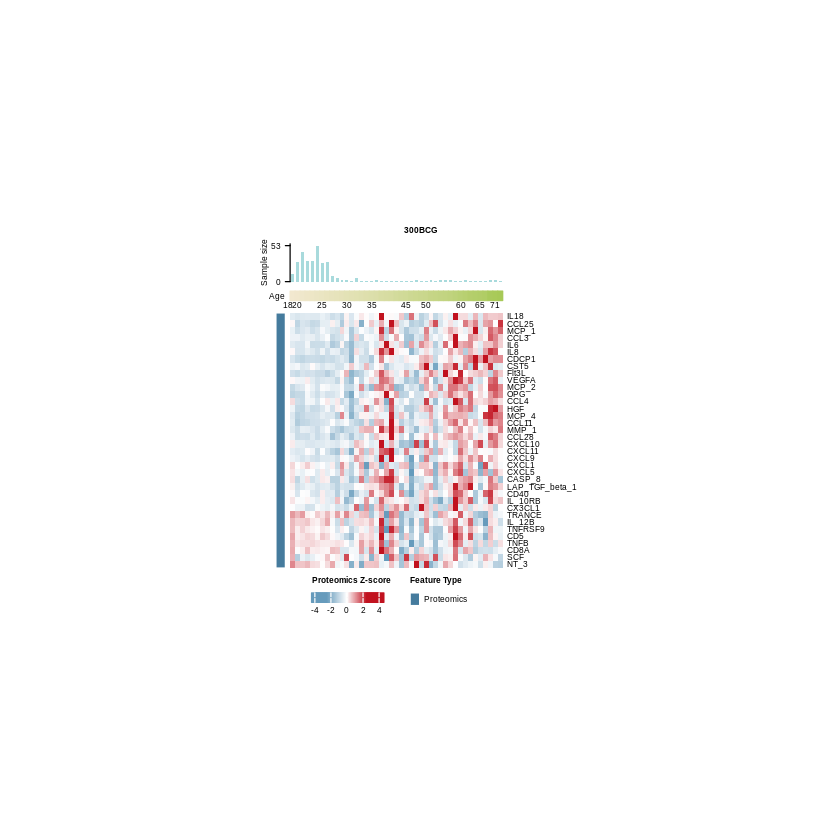

In [7]:
###nature style
# ========== Change 1: Add one line (Nature-style font, 6 pt) ==========
font_pt <- 5
row_height_mm <- 1.5 
heatmap_width_mm <- 45

age_labels[age_sorted == 70] <- "" #hide 70，overlap in the fig
# ========== Change 2: Add/update these in Heatmap() ==========
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Proteomics Z-score",
  height = unit(nrow(protein_data_zscore) * row_height_mm, "mm"),
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  row_names_gp = gpar(fontsize = font_pt),              # ADD
  column_names_gp = gpar(fontsize = font_pt),           # ADD
  col = protein_col_fun,
  row_dend_reorder = FALSE,
  width = unit(heatmap_width_mm, "mm"),
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun, height = unit(2, "mm")),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = font_pt), rot = 0),  
    annotation_name_side = "left",
    annotation_name_gp = gpar(fontsize = font_pt)
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(2, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE,
  heatmap_legend_param = list(                          # ADD this block
    title_gp = gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = gpar(fontsize = font_pt),
      direction = "horizontal",
    legend_width = unit(15, "mm"),          
    grid_height = unit(2, "mm")    
  )
)


# ========== Change 3: Feature Type legend font ==========
feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  at = c("Proteomics"),
  legend_gp = gpar(fill = c("#457b9d")),
  labels_gp = gpar(fontsize = font_pt),
    grid_height = unit(2, "mm"),    
  grid_width = unit(2, "mm")    
)


# ========== Change 4: Sample count axis font ==========
sample_count_anno <- HeatmapAnnotation(
   `Sample size` = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(0.8, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = font_pt)
    ),
    border = FALSE
  ),
  annotation_name_side = "left",
  annotation_name_gp = gpar(fontsize = font_pt)
)

heatmap_combined_separate <- sample_count_anno %v% protein_heatmap

# ========== Change 5: PDF size (Nature double-column) ==========
pdf("/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_zscore_cluster_samefeature_order(500fg)_nature_gender.pdf", width = 3.46, height = 3.5, onefile = FALSE)

draw(
  heatmap_combined_separate,
  column_title = "300BCG",                    
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
   annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE,
  legend_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  legend_labels_gp = gpar(fontsize = font_pt),
  legend_grid_height = unit(2, "mm"),
  legend_grid_width = unit(2, "mm"),
)

dev.off()

#29. **Display separate version on screen**
draw(
  heatmap_combined_separate,
  column_title = "300BCG",                    
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
   annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
    merge_legends = TRUE
)

pdf 
  2

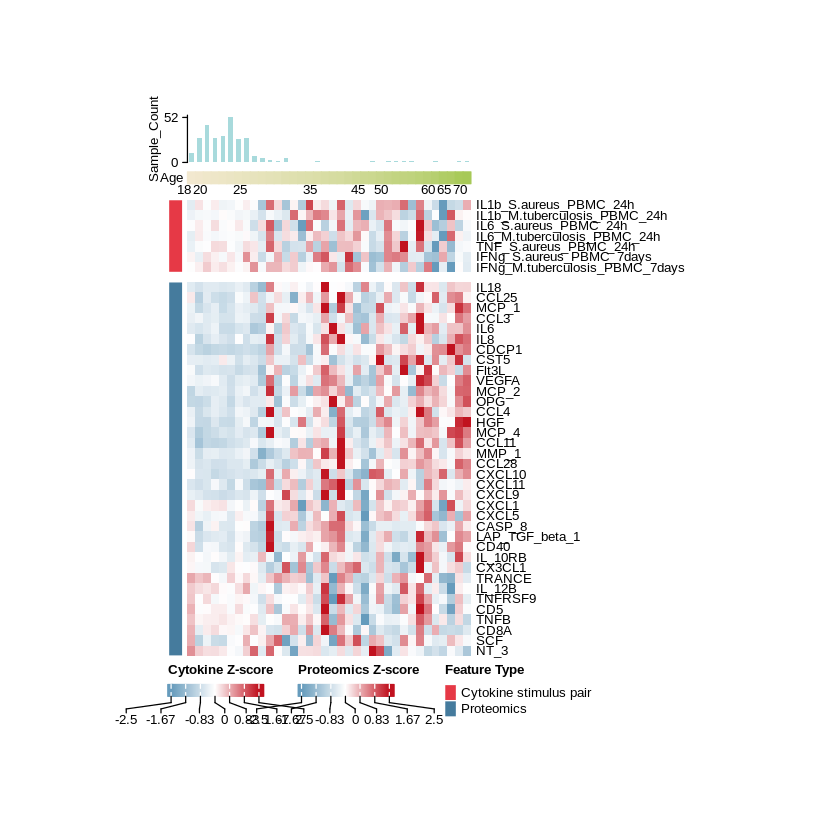

In [10]:
###add cytokine version
# 0) basic matrix
heatmap_data <- merged_data[, !(colnames(merged_data) %in% c("Sample_ID", "Age"))]

# 1) sort by age
sorted_indices <- order(merged_data$Age, na.last = FALSE)
heatmap_data_sorted <- heatmap_data[sorted_indices, , drop = FALSE]
age_sorted_raw <- merged_data$Age[sorted_indices]

# 2) remove NA rows and sync age
valid_rows <- complete.cases(heatmap_data_sorted)
heatmap_data_sorted <- heatmap_data_sorted[valid_rows, , drop = FALSE]
age_sorted_raw <- age_sorted_raw[valid_rows]

# 3) group by age median (dplyr 1.1+ syntax)
heatmap_data_sorted <- as.data.frame(heatmap_data_sorted)
heatmap_data_sorted$Age <- age_sorted_raw

heatmap_data_grouped <- heatmap_data_sorted %>%
  group_by(Age) %>%
  summarise(across(everything(), \(x) median(x, na.rm = TRUE))) %>%
  ungroup() %>%
  arrange(Age)

age_sorted <- heatmap_data_grouped$Age
heatmap_data_grouped_matrix <- as.matrix(dplyr::select(heatmap_data_grouped, -Age))

# 4) split cytokine/protein with fixed order
# cytokine order: keep current cytokine_common column order (your 7 cytokines)
cytokine_cols_use <- colnames(cytokine_common)[colnames(cytokine_common) %in% colnames(heatmap_data_grouped_matrix)]

# protein order: strictly follow 500fg reference order
protein_cols_use <- protein_500fg_names[protein_500fg_names %in% colnames(heatmap_data_grouped_matrix)]

cytokine_data_original <- heatmap_data_grouped_matrix[, cytokine_cols_use, drop = FALSE]
protein_data_original  <- heatmap_data_grouped_matrix[, protein_cols_use, drop = FALSE]

# transpose: rows=features, cols=age groups
cytokine_data <- t(cytokine_data_original)
protein_data  <- t(protein_data_original)

# 5) sample counts aligned to age_sorted
age_counts <- as.data.frame(table(merged_data$Age))
colnames(age_counts) <- c("Age", "Count")
age_counts$Age <- as.numeric(as.character(age_counts$Age))

sample_counts <- age_counts$Count[match(age_sorted, age_counts$Age)]
sample_counts[is.na(sample_counts)] <- 0

# 6) age labels (recompute to avoid length mismatch)
age_labels <- ifelse(
  age_sorted %in% c(min(age_sorted), max(age_sorted)) | age_sorted %% 5 == 0,
  as.character(age_sorted),
  ""
)

# optional: hide one label if overlap
# age_labels[age_sorted == 70] <- ""

# 7) z-score function
zscore_data <- function(data_matrix) {
  zscore_matrix <- t(apply(data_matrix, 1, function(x) {
    x_mean <- mean(x, na.rm = TRUE)
    x_sd <- sd(x, na.rm = TRUE)
    if (is.na(x_sd) || x_sd == 0) return(rep(0, length(x)))
    (x - x_mean) / x_sd
  }))
  return(zscore_matrix)
}

cytokine_data_zscore <- zscore_data(cytokine_data)
protein_data_zscore  <- zscore_data(protein_data)

# 8) color scales
cytokine_range <- range(cytokine_data_zscore, na.rm = TRUE)
protein_range  <- range(protein_data_zscore, na.rm = TRUE)

cytokine_limit <- min(max(abs(cytokine_range)), 2.5)
protein_limit  <- min(max(abs(protein_range)), 2.5)

cytokine_col_fun <- colorRamp2(
  breaks = seq(-cytokine_limit, cytokine_limit, length.out = 100),
  colors = colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)

protein_col_fun <- colorRamp2(
  breaks = seq(-protein_limit, protein_limit, length.out = 100),
  colors = colorRampPalette(c("#669bbc", "white", "#c1121f"))(100)
)

cytokine_breaks <- round(seq(-cytokine_limit, cytokine_limit, length.out = 7), 2)
protein_breaks  <- round(seq(-protein_limit,  protein_limit,  length.out = 7), 2)

age_col_fun <- colorRamp2(
  breaks = c(min(age_sorted), max(age_sorted)),
  colors = c("#f2e8cf", "#a7c957")
)

# 9) safety checks to prevent annotation length error
stopifnot(
  length(age_sorted) == ncol(cytokine_data_zscore),
  length(age_sorted) == ncol(protein_data_zscore),
  length(age_labels) == length(age_sorted),
  length(sample_counts) == length(age_sorted)
)

# 10) style
font_pt <- 8
row_height_mm <- 2.2
heatmap_width_mm <- 60

# 11) cytokine heatmap
cytokine_heatmap <- Heatmap(
  cytokine_data_zscore,
  name = "Cytokine Z-score",
  height = unit(nrow(cytokine_data_zscore) * row_height_mm, "mm"),
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = font_pt),
  col = cytokine_col_fun,
  row_dend_reorder = FALSE,
  width = unit(heatmap_width_mm, "mm"),
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun, height = unit(2.5, "mm")),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = font_pt), rot = 0),
    annotation_name_side = "left",
    annotation_name_gp = gpar(fontsize = font_pt)
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#e63946", col = "white"),
      width = unit(3, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE,
  heatmap_legend_param = list(
    title_gp = gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = gpar(fontsize = font_pt),
    at = cytokine_breaks,
    direction = "horizontal",
    legend_width = unit(20, "mm"),
    grid_height = unit(2.5, "mm")
  )
)

# 12) protein heatmap
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Proteomics Z-score",
  height = unit(nrow(protein_data_zscore) * row_height_mm, "mm"),
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  row_names_gp = gpar(fontsize = font_pt),
  column_names_gp = gpar(fontsize = font_pt),
  col = protein_col_fun,
  row_dend_reorder = FALSE,
  width = unit(heatmap_width_mm, "mm"),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(3, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE,
  heatmap_legend_param = list(
    title_gp = gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = gpar(fontsize = font_pt),
    at = protein_breaks,
    direction = "horizontal",
    legend_width = unit(20, "mm"),
    grid_height = unit(2.5, "mm")
  )
)

# 13) legends
feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  at = c("Cytokine stimulus pair", "Proteomics"),
  legend_gp = gpar(fill = c("#e63946", "#457b9d")),
  labels_gp = gpar(fontsize = font_pt),
  grid_height = unit(2.5, "mm"),
  grid_width = unit(2.5, "mm")
)

# 14) sample count annotation
sample_count_anno <- HeatmapAnnotation(
  Sample_Count = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(1.0, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = font_pt)
    ),
    border = FALSE
  ),
  annotation_name_side = "left",
  annotation_name_gp = gpar(fontsize = font_pt)
)

# 15) combine
heatmap_combined_separate <- sample_count_anno %v% (cytokine_heatmap %v% protein_heatmap)

# 16) save PDF
pdf(
  "/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_zscore_cluster_samefeature_order(500fg)_nature_gender_cytokine.pdf",
  width = 6.5, height = 9.0, onefile = FALSE
)

draw(
  heatmap_combined_separate,
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE,
  padding = unit(c(8, 8, 8, 8), "mm")
)

dev.off()

# 17) display in notebook
draw(
  heatmap_combined_separate,
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE,
  padding = unit(c(4, 4, 4, 4), "mm")
)

pdf 
  2

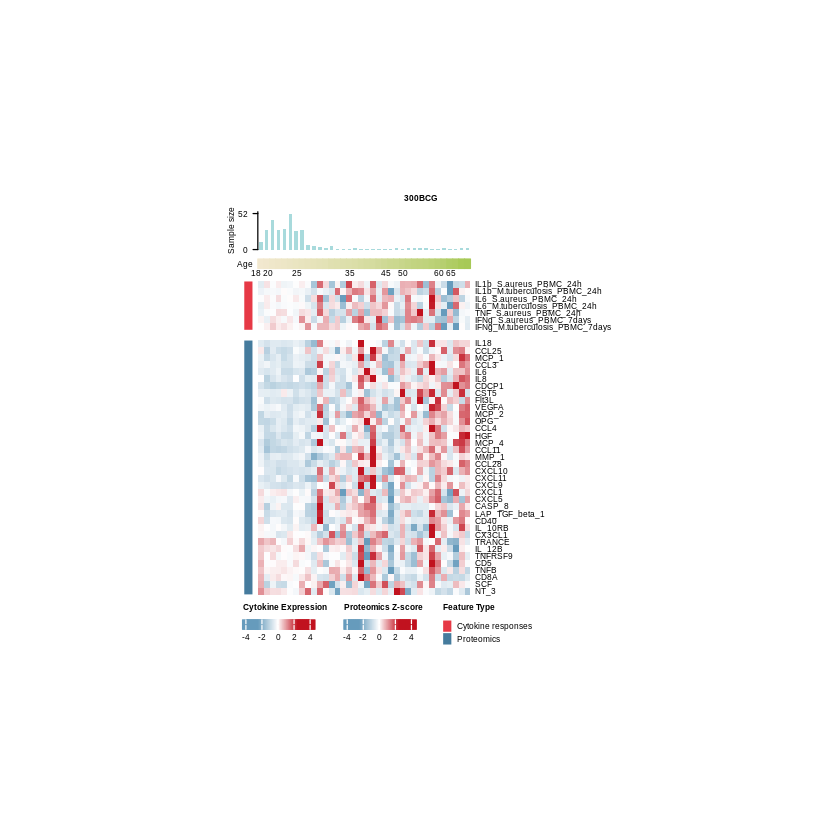

In [15]:
### nature style ###add cytokine
font_pt <- 5
row_height_mm <- 1.5
heatmap_width_mm <- 45

age_labels[age_sorted == 70] <- ""

# cytokine heatmap
cytokine_heatmap <- Heatmap(
  cytokine_data_zscore,
  name = "Cytokine Expression",
  height = unit(nrow(cytokine_data_zscore) * row_height_mm, "mm"),
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = FALSE,
  row_names_gp = gpar(fontsize = font_pt),
  col = cytokine_col_fun,
  row_dend_reorder = FALSE,
  width = unit(heatmap_width_mm, "mm"),
  top_annotation = HeatmapAnnotation(
    Age = anno_simple(age_sorted, col = age_col_fun, height = unit(2, "mm")),
    Age_Label = anno_text(age_labels, gp = gpar(fontsize = font_pt), rot = 0),
    annotation_name_side = "left",
    annotation_name_gp = gpar(fontsize = font_pt)
  ),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#e63946", col = "white"),
      width = unit(2, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE,
  heatmap_legend_param = list(
    title_gp = gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = gpar(fontsize = font_pt),
    direction = "horizontal",
    legend_width = unit(15, "mm"),
    grid_height = unit(2, "mm")
  )
)

# protein heatmap (unchanged logic)
protein_heatmap <- Heatmap(
  protein_data_zscore,
  name = "Proteomics Z-score",
  height = unit(nrow(protein_data_zscore) * row_height_mm, "mm"),
  cluster_rows = FALSE,
  cluster_columns = FALSE,
  show_row_names = TRUE,
  show_column_names = TRUE,
  row_names_gp = gpar(fontsize = font_pt),
  column_names_gp = gpar(fontsize = font_pt),
  col = protein_col_fun,
  row_dend_reorder = FALSE,
  width = unit(heatmap_width_mm, "mm"),
  left_annotation = rowAnnotation(
    Feature_Type = anno_block(
      gp = gpar(fill = "#457b9d", col = "white"),
      width = unit(2, "mm")
    )
  ),
  rect_gp = gpar(col = NA),
  border = FALSE,
  heatmap_legend_param = list(
    title_gp = gpar(fontsize = font_pt, fontface = "bold"),
    labels_gp = gpar(fontsize = font_pt),
    direction = "horizontal",
    legend_width = unit(15, "mm"),
    grid_height = unit(2, "mm")
  )
)

feature_type_legend_separate <- Legend(
  title = "Feature Type",
  title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  at = c("Cytokine responses", "Proteomics"),
  legend_gp = gpar(fill = c("#e63946", "#457b9d")),
  labels_gp = gpar(fontsize = font_pt),
  grid_height = unit(2, "mm"),
  grid_width = unit(2, "mm")
)

sample_count_anno <- HeatmapAnnotation(
  `Sample size` = anno_barplot(
    sample_counts,
    gp = gpar(fill = "#a8dadc", col = NA, lwd = 0),
    height = unit(0.8, "cm"),
    axis_param = list(
      at = c(0, max(sample_counts)),
      labels = c("0", max(sample_counts)),
      gp = gpar(fontsize = font_pt)
    ),
    border = FALSE
  ),
  annotation_name_side = "left",
  annotation_name_gp = gpar(fontsize = font_pt)
)

# combine: cytokine on top, protein below
heatmap_combined_separate <- sample_count_anno %v% (cytokine_heatmap %v% protein_heatmap)

pdf("/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_zscore_samefeature_order(500fg)_nature_gender_cytokine.pdf",
    width = 3.46, height = 3.9, onefile = FALSE)

draw(
  heatmap_combined_separate,
  column_title = "300BCG",
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE
)
dev.off()

#29. **Display separate version on screen**
draw(
  heatmap_combined_separate,
  column_title = "300BCG",
  column_title_side = "top",
  column_title_gp = gpar(fontsize = font_pt, fontface = "bold"),
  show_heatmap_legend = TRUE,
  show_annotation_legend = TRUE,
  annotation_legend_list = list(feature_type_legend_separate),
  heatmap_legend_side = "bottom",
  annotation_legend_side = "bottom",
  merge_legends = TRUE
)

In [8]:
save.image("/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_samefeature(500fg)_nature_gender.Rdata")

In [16]:
save.image("/vol/projects/yzhang/300BCG/output/02_protein/linear_age/300bcg_heatmap_samefeature(500fg)_nature_gender_cytokine.Rdata")

In [83]:
out_300bcg <- list(
  protein_data = protein_data,
  sample_counts       = sample_counts,
  age_sorted          = age_sorted,
  age_labels          = age_labels,
  age_col_fun         = age_col_fun
)
saveRDS(out_300bcg, "/vol/projects/yzhang/300BCG/output/02_protein/linear_age/heatmap_300bcg_nature.rds")